# 05 Logistic Regression Modeling

This notebook trains a Logistic Regression model for the AgriCredit Resilience project.

The goal is to predict the target feature:

`financial_vulnerability`

Logistic Regression is useful because it can estimate the probability that a household is financially vulnerable. This supports the project goal of building a responsible decision-support system.

Main tasks:

1. Load the final ABT
2. Select features and target
3. Split data into training and testing sets
4. Encode categorical features
5. Scale numeric features
6. Train a Logistic Regression model
7. Evaluate model performance
8. Analyze predicted probabilities
9. Interpret model coefficients
10. Save the trained model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import joblib

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

ABT_PATH = PROCESSED_DATA_DIR / "farmer_vulnerability_abt.csv"

ABT_PATH

PosixPath('/Users/isaacaung/Desktop/agricredit-resilience/data/processed/farmer_vulnerability_abt.csv')

In [3]:
abt = pd.read_csv(ABT_PATH)

abt.head()

,household_id,state_region,township,household_size,female_headed_household,disability_present,displacement_status,monthly_income,has_debt,total_debt,...,cash_food_assistance_per_person,household_meb_requirement,income_to_meb_ratio,meb_gap,coverage_rate,coverage_gap_ratio,response_gap,number_of_partners_active,vulnerability_score,financial_vulnerability
0,HH00001,Magway,Magway,6,0,0,IDP,610149.0,1,851624,...,30000,330000,1.848936,280149.0,0.380,0.620,15359,21,3,1
1,HH00002,Ayeyarwady,Pathein,8,0,0,Resident,284061.0,1,801819,...,35000,440000,0.645593,-155939.0,0.424,0.576,56238,21,4,1
2,HH00003,Shan North,Lashio,4,0,0,Resident,50000.0,0,0,...,50000,240000,0.208333,-190000.0,0.607,0.393,9415,17,5,1
3,HH00004,Kayin,Hpa-An,4,0,0,Resident,101947.0,1,667989,...,40000,260000,0.392104,-158053.0,0.387,0.613,128076,20,3,1
4,HH00005,Kayin,Myawaddy,6,0,0,Returnee,675893.0,1,593253,...,40000,390000,1.733059,285893.0,0.387,0.613,128076,20,3,1


In [4]:
print(f"Rows: {abt.shape[0]}")
print(f"Columns: {abt.shape[1]}")

abt["financial_vulnerability"].value_counts().sort_index()

Rows: 1500
Columns: 44


financial_vulnerability
0    555
1    945
Name: count, dtype: int64

## Dataset Check

The final ABT contains one row per household. The target feature is `financial_vulnerability`.

The target has two classes:

- `0` = not financially vulnerable
- `1` = financially vulnerable

The dataset is slightly imbalanced because there are more vulnerable households than not vulnerable households. Because of this, evaluation should include precision, recall, F1-score, ROC-AUC, and the confusion matrix, not only accuracy.

In [5]:
target_column = "financial_vulnerability"

y = abt[target_column]

y.head()

0    1
1    1
2    1
3    1
4    1
Name: financial_vulnerability, dtype: int64

In [6]:
feature_columns = [
    # Location/context
    "state_region",

    # Household characteristics
    "household_size",
    "female_headed_household",
    "disability_present",
    "displacement_status",

    # Financial features
    "monthly_income",
    "has_debt",
    "total_debt",
    "monthly_debt_repayment",
    "savings_duration_weeks",
    "debt_to_income_ratio",
    "monthly_debt_repayment_ratio",

    # Market access
    "market_access",

    # Agriculture features
    "is_farming_household",
    "main_crop",
    "farm_size_acres",
    "irrigation_access",
    "fertilizer_cost",
    "crop_damage_recent",

    # Coping and basic needs
    "rCSI_score",
    "basic_needs_score",

    # Market context
    "basic_food_basket_change_1y",
    "rice_price_change_1y",
    "fuel_price_change_1y",
    "market_disruption_score",
    "market_pressure_score",

    # MEB features
    "mpca_per_person",
    "household_meb_requirement",
    "income_to_meb_ratio",
    "meb_gap",

    # Assistance coverage
    "coverage_rate",
    "coverage_gap_ratio",
    "response_gap",
    "number_of_partners_active",
]

X = abt[feature_columns].copy()

X.head()

,state_region,household_size,female_headed_household,disability_present,displacement_status,monthly_income,has_debt,total_debt,monthly_debt_repayment,savings_duration_weeks,...,market_disruption_score,market_pressure_score,mpca_per_person,household_meb_requirement,income_to_meb_ratio,meb_gap,coverage_rate,coverage_gap_ratio,response_gap,number_of_partners_active
0,Magway,6,0,0,IDP,610149.0,1,851624,150329,1,...,1,91.4,55000,330000,1.848936,280149.0,0.380,0.620,15359,21
1,Ayeyarwady,8,0,0,Resident,284061.0,1,801819,95454,4,...,1,70.9,55000,440000,0.645593,-155939.0,0.424,0.576,56238,21
2,Shan North,4,0,0,Resident,50000.0,0,0,0,2,...,2,78.5,60000,240000,0.208333,-190000.0,0.607,0.393,9415,17
3,Kayin,4,0,0,Resident,101947.0,1,667989,60245,2,...,1,66.5,65000,260000,0.392104,-158053.0,0.387,0.613,128076,20
4,Kayin,6,0,0,Returnee,675893.0,1,593253,81094,1,...,1,66.5,65000,390000,1.733059,285893.0,0.387,0.613,128076,20


In [7]:
X.dtypes

state_region                        str
household_size                    int64
female_headed_household           int64
disability_present                int64
displacement_status                 str
monthly_income                  float64
has_debt                          int64
total_debt                        int64
monthly_debt_repayment            int64
savings_duration_weeks            int64
debt_to_income_ratio            float64
monthly_debt_repayment_ratio    float64
market_access                   float64
is_farming_household              int64
main_crop                           str
farm_size_acres                 float64
irrigation_access                 int64
fertilizer_cost                 float64
crop_damage_recent                int64
rCSI_score                      float64
basic_needs_score                 int64
basic_food_basket_change_1y     float64
rice_price_change_1y            float64
fuel_price_change_1y            float64
market_disruption_score           int64


In [8]:
categorical_features = [
    "state_region",
    "displacement_status",
    "main_crop",
]

numeric_features = [
    col for col in feature_columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumber of numeric features:")
print(len(numeric_features))

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['state_region', 'displacement_status', 'main_crop']

Number of numeric features:
31

Numeric features:
['household_size', 'female_headed_household', 'disability_present', 'monthly_income', 'has_debt', 'total_debt', 'monthly_debt_repayment', 'savings_duration_weeks', 'debt_to_income_ratio', 'monthly_debt_repayment_ratio', 'market_access', 'is_farming_household', 'farm_size_acres', 'irrigation_access', 'fertilizer_cost', 'crop_damage_recent', 'rCSI_score', 'basic_needs_score', 'basic_food_basket_change_1y', 'rice_price_change_1y', 'fuel_price_change_1y', 'market_disruption_score', 'market_pressure_score', 'mpca_per_person', 'household_meb_requirement', 'income_to_meb_ratio', 'meb_gap', 'coverage_rate', 'coverage_gap_ratio', 'response_gap', 'number_of_partners_active']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training rows: 1200
Testing rows: 300

Training target distribution:
financial_vulnerability
0    0.37
1    0.63
Name: proportion, dtype: float64

Testing target distribution:
financial_vulnerability
0    0.37
1    0.63
Name: proportion, dtype: float64


## Train/Test Split

The dataset was split into training and testing sets. The training set is used to train the Logistic Regression model, while the testing set is used to evaluate how well the model performs on unseen data.

A stratified split was used so that the target distribution remains similar in both training and testing sets.

## Build Logistic Regression Pipeline

Logistic Regression requires numeric input. The categorical columns will be converted using one-hot encoding.

Unlike Decision Trees, Logistic Regression is affected by feature scale. For example, `monthly_income` has large values, while `market_access` is only 0 or 1. Therefore, numeric features will be scaled using `StandardScaler`.

The pipeline will include:

1. One-hot encoding for categorical features
2. Standard scaling for numeric features
3. Logistic Regression model

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", StandardScaler(), numeric_features),
    ]
)

logistic_regression_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
)

logistic_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_regression_model),
    ]
)

logistic_regression_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defau

In [11]:
logistic_regression_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [12]:
y_pred = logistic_regression_pipeline.predict(X_test)

y_pred_proba = logistic_regression_pipeline.predict_proba(X_test)[:, 1]

print("First 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 vulnerability probabilities:")
print(y_pred_proba[:10])

First 10 predicted classes:
[1 1 1 1 1 1 1 1 1 0]

First 10 vulnerability probabilities:
[0.59157207 0.99619439 0.95440421 0.9735938  0.68162785 0.78125153
 0.72570988 0.9993658  0.99750571 0.4926786 ]


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

model_metrics = {
    "accuracy": round(accuracy, 4),
    "precision": round(precision, 4),
    "recall": round(recall, 4),
    "f1_score": round(f1, 4),
    "roc_auc": round(roc_auc, 4),
}

model_metrics

{'accuracy': 0.8567,
 'precision': 0.9056,
 'recall': 0.8624,
 'f1_score': 0.8835,
 'roc_auc': 0.9484}

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.85      0.81       111
           1       0.91      0.86      0.88       189

    accuracy                           0.86       300
   macro avg       0.84      0.85      0.85       300
weighted avg       0.86      0.86      0.86       300



### Observation

The Logistic Regression model achieved strong performance on the test set. The model reached about 86% accuracy, with strong precision, recall, and F1-score for the financially vulnerable class.

The ROC-AUC score is about 0.95, which suggests that the model is very good at separating vulnerable households from not vulnerable households using probability scores.

Compared with the Decision Tree model, Logistic Regression performs better on accuracy, precision, recall, and F1-score. However, the Decision Tree remains useful because it provides simple if-then rules, while Logistic Regression is especially useful for probability-based risk scoring.

In [15]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[ 94,  17],
       [ 26, 163]])

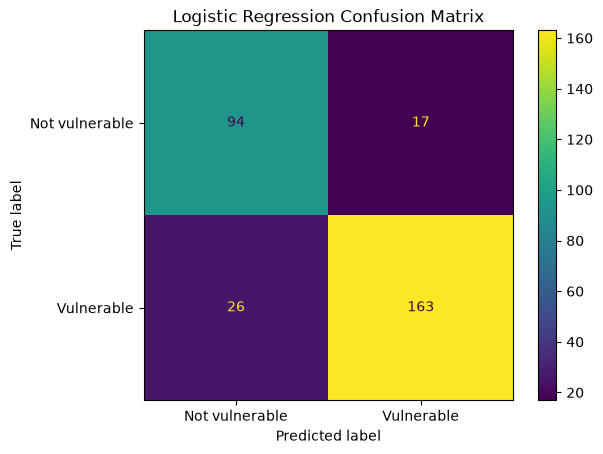

In [16]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not vulnerable", "Vulnerable"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Confusion Matrix Explanation

The confusion matrix shows how many test records were correctly and incorrectly classified.

- True Negative: not vulnerable households correctly predicted as not vulnerable
- False Positive: not vulnerable households incorrectly predicted as vulnerable
- False Negative: vulnerable households incorrectly predicted as not vulnerable
- True Positive: vulnerable households correctly predicted as vulnerable

For this project, false negatives are especially important because they represent vulnerable households that the model failed to identify.

### Observation

The Logistic Regression confusion matrix shows that the model correctly predicted 94 not vulnerable households and 163 vulnerable households.

The model made 17 false positive errors, meaning some not vulnerable households were predicted as vulnerable. It also made 26 false negative errors, meaning some vulnerable households were missed.

For this project, false negatives are especially important because they represent vulnerable households that the model failed to identify. Logistic Regression correctly identified 163 out of 189 vulnerable households, giving a vulnerable-class recall of about 86%.

Compared with the Decision Tree model, Logistic Regression missed fewer vulnerable households and performed better overall.

## Predicted Probability Analysis

Logistic Regression can produce probability scores. In this project, the probability score represents the model's estimated probability that a household is financially vulnerable.

This is useful because the system can show different risk levels, instead of only showing a binary prediction.

In [17]:
probability_results = X_test.copy()

probability_results["actual_financial_vulnerability"] = y_test.values
probability_results["predicted_financial_vulnerability"] = y_pred
probability_results["vulnerability_probability"] = y_pred_proba

probability_results[[
    "actual_financial_vulnerability",
    "predicted_financial_vulnerability",
    "vulnerability_probability",
]].head(10)

,actual_financial_vulnerability,predicted_financial_vulnerability,vulnerability_probability
1457,0,1,0.591572
902,1,1,0.996194
1049,1,1,0.954404
610,1,1,0.973594
1168,0,1,0.681628
1387,1,1,0.781252
100,1,1,0.725710
1407,1,1,0.999366
364,1,1,0.997506
243,0,0,0.492679


In [18]:
def assign_risk_level(probability: float) -> str:
    if probability < 0.40:
        return "Low risk"
    elif probability < 0.70:
        return "Medium risk"
    else:
        return "High risk"


probability_results["risk_level"] = probability_results[
    "vulnerability_probability"
].apply(assign_risk_level)

probability_results[[
    "actual_financial_vulnerability",
    "predicted_financial_vulnerability",
    "vulnerability_probability",
    "risk_level",
]].head(10)

,actual_financial_vulnerability,predicted_financial_vulnerability,vulnerability_probability,risk_level
1457,0,1,0.591572,Medium risk
902,1,1,0.996194,High risk
1049,1,1,0.954404,High risk
610,1,1,0.973594,High risk
1168,0,1,0.681628,Medium risk
1387,1,1,0.781252,High risk
100,1,1,0.725710,High risk
1407,1,1,0.999366,High risk
364,1,1,0.997506,High risk
243,0,0,0.492679,Medium risk


In [19]:
probability_results["risk_level"].value_counts()

risk_level
High risk      158
Low risk       108
Medium risk     34
Name: count, dtype: int64

In [20]:
probability_results.groupby("actual_financial_vulnerability")[
    "vulnerability_probability"
].describe()

,count,mean,std,min,25%,50%,75%,max
actual_financial_vulnerability,,,,,,,,
0,111.0,0.176883,0.266582,0.000003,0.005644,0.033106,0.210306,0.92427
1,189.0,0.834489,0.263579,0.030264,0.785763,0.971286,0.998400,1.00000


In [21]:
probability_results.sort_values(
    by="vulnerability_probability",
    ascending=False
)[[
    "state_region",
    "household_size",
    "monthly_income",
    "debt_to_income_ratio",
    "rCSI_score",
    "market_access",
    "income_to_meb_ratio",
    "vulnerability_probability",
    "risk_level",
    "actual_financial_vulnerability",
    "predicted_financial_vulnerability",
]].head(10)

,state_region,household_size,monthly_income,debt_to_income_ratio,rCSI_score,market_access,income_to_meb_ratio,vulnerability_probability,risk_level,actual_financial_vulnerability,predicted_financial_vulnerability
981,Shan North,3,50000.0,8.107580,22.0,0.0,0.277778,1.000000,High risk,1,1
1320,Magway,4,89428.0,9.746612,31.0,0.0,0.406491,1.000000,High risk,1,1
1396,Shan South,9,101183.0,10.676003,26.0,0.0,0.204410,1.000000,High risk,1,1
144,Tanintharyi,3,109436.0,9.132863,19.0,0.0,0.663248,1.000000,High risk,1,1
838,Sagaing,5,178098.0,6.553937,23.0,0.0,0.647629,1.000000,High risk,1,1
1026,Magway,7,270802.0,4.564316,22.0,0.0,0.703382,0.999999,High risk,1,1
949,Chin,5,478269.0,1.033820,32.0,0.0,1.006882,0.999999,High risk,1,1
345,Chin,5,282063.0,4.235245,21.0,0.0,0.593817,0.999999,High risk,1,1
1055,Tanintharyi,6,635393.0,2.001114,25.0,0.0,1.925433,0.999996,High risk,1,1
423,Shan South,4,308137.0,3.018612,32.0,0.0,1.400623,0.999994,High risk,1,1


In [22]:
probability_results["distance_from_50_percent"] = (
    probability_results["vulnerability_probability"] - 0.50
).abs()

probability_results.sort_values(
    by="distance_from_50_percent"
)[[
    "state_region",
    "household_size",
    "monthly_income",
    "debt_to_income_ratio",
    "rCSI_score",
    "market_access",
    "income_to_meb_ratio",
    "vulnerability_probability",
    "risk_level",
    "actual_financial_vulnerability",
    "predicted_financial_vulnerability",
]].head(10)

,state_region,household_size,monthly_income,debt_to_income_ratio,rCSI_score,market_access,income_to_meb_ratio,vulnerability_probability,risk_level,actual_financial_vulnerability,predicted_financial_vulnerability
189,Kachin,4,543777.0,1.808933,14.0,0.0,2.091450,0.495133,Medium risk,1,0
710,Shan North,9,303466.0,1.657998,17.0,1.0,0.561974,0.505972,Medium risk,1,1
243,Shan North,8,575356.0,1.679696,10.0,1.0,1.198658,0.492679,Medium risk,0,0
923,Mandalay,2,213151.0,4.965372,5.0,1.0,1.937736,0.478350,Medium risk,0,0
1245,Tanintharyi,6,50000.0,0.000000,16.0,1.0,0.151515,0.526800,Medium risk,0,1
265,Shan South,2,604456.0,0.581381,26.0,1.0,5.495055,0.470545,Medium risk,0,0
547,Shan South,5,330191.0,0.000000,13.0,1.0,1.200695,0.533615,Medium risk,0,1
231,Bago,2,303925.0,2.305858,16.0,1.0,2.762955,0.466074,Medium risk,1,0
544,Bago,9,379892.0,1.218596,18.0,1.0,0.767459,0.465294,Medium risk,1,0
227,Shan South,7,410718.0,0.000000,16.0,0.0,1.066800,0.460847,Medium risk,0,0


### Probability Analysis Observation

The predicted probability scores show how confident the Logistic Regression model is when predicting financial vulnerability.

High probability households can be interpreted as higher-risk households, while probabilities near 0.50 represent uncertain cases where the model is less confident.

This probability-based output is useful for the AgriCredit Resilience project because the system can support responsible decision-making. Instead of only giving a yes/no prediction, it can show a vulnerability probability and risk level.

### Probability Analysis Observation

The predicted probability results show that the Logistic Regression model separates vulnerable and not vulnerable households clearly.

Most truly not vulnerable households received low vulnerability probabilities, while most truly vulnerable households received high vulnerability probabilities. The average probability for not vulnerable households is about 0.18, while the average probability for vulnerable households is about 0.83.

The risk level distribution shows 158 high-risk households, 108 low-risk households, and 34 medium-risk households in the test set. The medium-risk group is useful because it represents cases where the model is less certain and may require manual review.

The highest-risk households have very high vulnerability probabilities and show strong risk indicators such as high debt-to-income ratio, high coping strategy score, no market access, and low income compared with MEB. This supports the project goal of using Logistic Regression for probability-based vulnerability scoring.

## Logistic Regression Coefficient Interpretation

Logistic Regression uses coefficients to show how each feature affects the prediction.

- Positive coefficient: increases the probability of financial vulnerability
- Negative coefficient: decreases the probability of financial vulnerability

This helps explain which factors are associated with higher or lower vulnerability risk.

In [23]:
encoded_feature_names = logistic_regression_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

logistic_model = logistic_regression_pipeline.named_steps["model"]

coefficients = logistic_model.coef_[0]

coefficient_table = pd.DataFrame({
    "feature": encoded_feature_names,
    "coefficient": coefficients,
})

coefficient_table["feature_clean"] = (
    coefficient_table["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

coefficient_table.head()

,feature,coefficient,feature_clean
0,categorical__state_region_Ayeyarwady,-0.983981,state_region_Ayeyarwady
1,categorical__state_region_Bago,0.147423,state_region_Bago
2,categorical__state_region_Chin,0.442720,state_region_Chin
3,categorical__state_region_Kachin,0.891528,state_region_Kachin
4,categorical__state_region_Kayah,-0.763741,state_region_Kayah


In [24]:
top_positive_coefficients = coefficient_table.sort_values(
    by="coefficient",
    ascending=False
).head(15)

top_positive_coefficients[["feature_clean", "coefficient"]]

,feature_clean,coefficient
39,crop_damage_recent,1.686077
33,monthly_debt_repayment_ratio,1.561275
40,rCSI_score,1.514861
32,debt_to_income_ratio,1.268975
29,total_debt,1.266968
46,market_pressure_score,1.136405
3,state_region_Kachin,0.891528
44,fuel_price_change_1y,0.679468
48,household_meb_requirement,0.670023
42,basic_food_basket_change_1y,0.624743


In [25]:
top_negative_coefficients = coefficient_table.sort_values(
    by="coefficient",
    ascending=True
).head(15)

top_negative_coefficients[["feature_clean", "coefficient"]]

,feature_clean,coefficient
34,market_access,-1.718711
41,basic_needs_score,-1.615423
0,state_region_Ayeyarwady,-0.983981
50,meb_gap,-0.966798
4,state_region_Kayah,-0.763741
5,state_region_Kayin,-0.693933
27,monthly_income,-0.690175
45,market_disruption_score,-0.574053
21,main_crop_Rice,-0.439576
28,has_debt,-0.397798


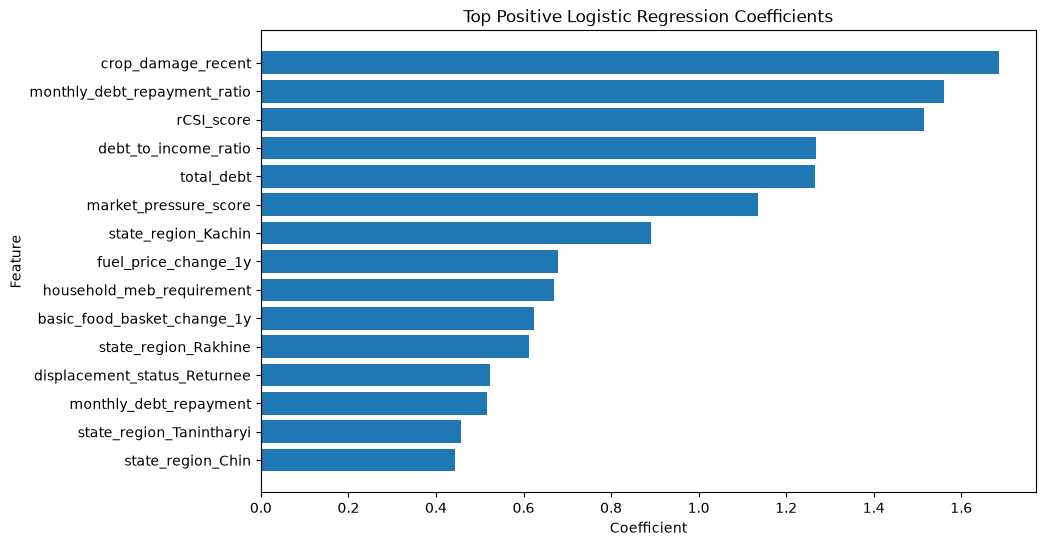

In [26]:
top_positive_plot = top_positive_coefficients.sort_values("coefficient")

plt.figure(figsize=(10, 6))

plt.barh(
    top_positive_plot["feature_clean"],
    top_positive_plot["coefficient"]
)

plt.title("Top Positive Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

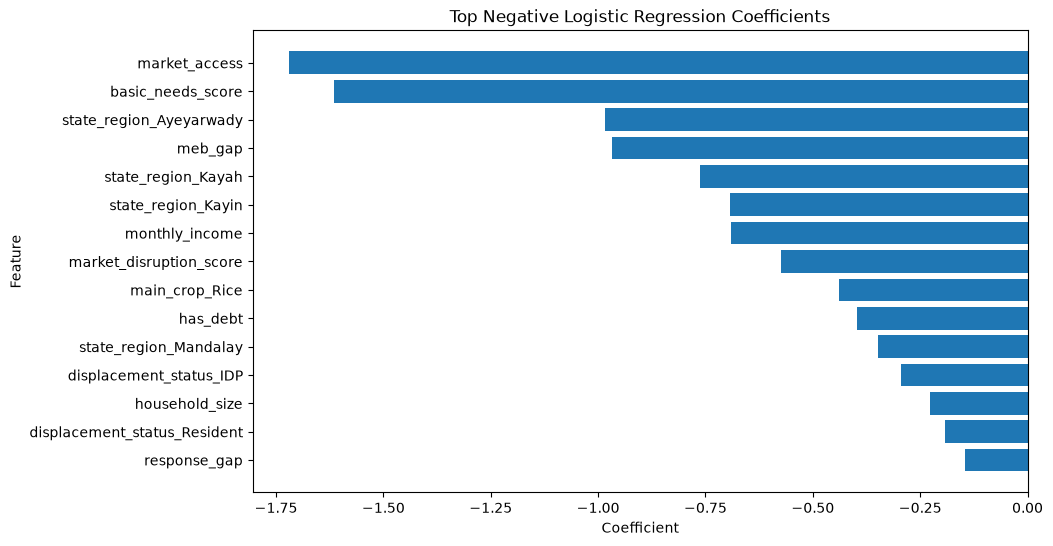

In [27]:
top_negative_plot = top_negative_coefficients.sort_values("coefficient", ascending=False)

plt.figure(figsize=(10, 6))

plt.barh(
    top_negative_plot["feature_clean"],
    top_negative_plot["coefficient"]
)

plt.title("Top Negative Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

### Coefficient Interpretation Observation

The Logistic Regression coefficients help explain which factors increase or decrease the predicted probability of financial vulnerability.

Positive coefficients are associated with higher vulnerability probability. These may include features such as higher debt pressure, higher coping strategy score, crop damage, market pressure, or poor market access.

Negative coefficients are associated with lower vulnerability probability. These may include features such as better income compared with MEB, better basic needs coverage, market access, or stronger financial conditions.

This coefficient interpretation supports the project goal because the model does not only give a prediction. It also helps explain the direction of influence for each feature.

### Coefficient Interpretation Observation

The Logistic Regression coefficients show which factors increase or decrease the predicted probability of financial vulnerability.

The strongest positive coefficients include `crop_damage_recent`, `monthly_debt_repayment_ratio`, `rCSI_score`, `debt_to_income_ratio`, `total_debt`, and `market_pressure_score`. This means households with recent crop damage, higher repayment pressure, higher coping strategy scores, higher debt pressure, and stronger market pressure are more likely to be predicted as financially vulnerable.

The strongest negative coefficients include `market_access`, `basic_needs_score`, `meb_gap`, and `monthly_income`. This means households with market access, better basic needs coverage, higher income surplus compared with MEB, and higher income are less likely to be predicted as financially vulnerable.

Some coefficients may look less intuitive because Logistic Regression considers all features together. Related variables can influence each other, so coefficient interpretation should focus on the strongest and most meaningful patterns rather than every single value.

In [28]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "logistic_regression_model.joblib"

joblib.dump(logistic_regression_pipeline, model_path)

model_path

PosixPath('/Users/isaacaung/Desktop/agricredit-resilience/models/logistic_regression_model.joblib')

In [29]:
loaded_model = joblib.load(model_path)

loaded_predictions = loaded_model.predict(X_test)
loaded_probabilities = loaded_model.predict_proba(X_test)[:, 1]

print("Loaded model accuracy:", round(accuracy_score(y_test, loaded_predictions), 4))
print("Loaded model ROC-AUC:", round(roc_auc_score(y_test, loaded_probabilities), 4))

Loaded model accuracy: 0.8567
Loaded model ROC-AUC: 0.9484


## Logistic Regression Modeling Summary

The Logistic Regression model was trained successfully to predict `financial_vulnerability`.

The model achieved about 86% accuracy on the test set and had a ROC-AUC score of about 0.95. This shows that the model performs well and can separate vulnerable households from not vulnerable households using probability scores.

The confusion matrix showed that the model correctly identified 163 vulnerable households and missed 26 vulnerable households. Because this project focuses on vulnerability detection, false negatives are especially important.

The probability analysis showed that most truly vulnerable households received high vulnerability probabilities, while most truly not vulnerable households received low probabilities. This supports the use of Logistic Regression for probability-based risk scoring.

The coefficient analysis showed that crop damage, debt repayment pressure, rCSI score, debt-to-income ratio, total debt, and market pressure increased vulnerability probability. Market access, better basic needs coverage, higher MEB gap, and higher income reduced vulnerability probability.

The trained Logistic Regression pipeline was saved to:

`models/logistic_regression_model.joblib`